# Importing libraries

In [74]:
from pathlib import Path
from tabulate import tabulate

# Basic wrangling and external features
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Mapping
import geopandas as gpd
import contextily as cx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Set up and prioritization function

In [75]:
# Full model parquet 
DATA_PATH = Path("../outputs/model_1_results.parquet")

opt_df = pd.read_parquet(DATA_PATH)

print(opt_df.shape)
opt_df.head()

(4069942, 33)


,station_id,datetime_hour,departures,arrivals,net_flow,abs_net_flow,year,month,day,hour,...,nearest_metro_name,distance_to_metro_m,lag_1,lag_24,actual_departures,pred_departures_linear,pred_departures_poisson,pred_departures_DT,pred_departures_RF,pred_departures_XGB
0,1,2025-01-01 00:00:00,0,4,-4,4,2025,1,1,0,...,Constituyentes,573.702169,0.0,10.0,0,1.450212,3.037410,0.692229,0.575649,0.913503
1,1,2025-01-01 05:00:00,1,3,-2,2,2025,1,1,5,...,Constituyentes,573.702169,0.0,17.0,1,1.516128,3.173418,1.034285,1.078248,1.106444
2,1,2025-01-01 06:00:00,1,3,-2,2,2025,1,1,6,...,Constituyentes,573.702169,1.0,19.0,1,2.190854,3.300267,1.829087,2.196620,1.872880
3,1,2025-01-01 07:00:00,2,1,1,1,2025,1,1,7,...,Constituyentes,573.702169,1.0,28.0,2,4.390025,3.705905,1.054614,2.196620,2.928664
4,1,2025-01-01 08:00:00,2,0,2,2,2025,1,1,8,...,Constituyentes,573.702169,2.0,16.0,2,3.685929,3.413255,1.363636,3.180265,3.620491


In [ ]:
# Hour-level deficit, surplus, imbalance
def priority_optimization(opt_df, period_name, period_filter):
    temp = opt_df.loc[period_filter].copy()

    # Deficit (needed)
    temp["pred_deficit_hour"] = (temp["pred_departures_XGB"] - temp["arrivals"]).clip(lower=0)

    # Surplus (available)
    temp["pred_surplus_hour"] = (temp["arrivals"] - temp["pred_departures_XGB"]).clip(lower=0)

    # Absoltue Imbalance 
    temp["pred_abs_imbalance_hour"] = (temp["pred_departures_XGB"] - temp["arrivals"]).abs()

    station_metrics = (
        temp
        .groupby("station_id")
        .agg(
            d_i=("pred_departures_XGB", "sum"),
            B_i=("pred_abs_imbalance_hour", "sum"),
            pred_deficit=("pred_deficit_hour", "sum"),
            pred_surplus=("pred_surplus_hour", "sum"),
            max_hourly_deficit=("pred_deficit_hour", "max"),
            capacity=("capacity", "first"),
            lat=("lat", "first"),
            lon=("lon", "first"),
            net_flow=("net_flow", "sum"),                
            historical_imbalance=("abs_net_flow", "sum")
        )
        .reset_index()
    )

    station_metrics["period"] = period_name

    denominator = station_metrics["d_i"].sum()

    # Based on Maya-Duque priority score 
    station_metrics["priority_score"] = (
        station_metrics["d_i"] * station_metrics["B_i"]
    ) / denominator

    # Each station has an intrinsic capacity, so predicted demand and its optimization should be constrained
    station_metrics["bikes_needed"] = np.minimum(
        station_metrics["max_hourly_deficit"],
        station_metrics["capacity"]
    )

    #Quantile based selection, similar to the EDA
    station_metrics["top_priority"] = (
        station_metrics["priority_score"]
        >= station_metrics["priority_score"].quantile(0.95)
    )

    return station_metrics.sort_values("priority_score", ascending=False)

In [77]:
# From station-level panel build peak periods
opt_df["datetime_hour"] = pd.to_datetime(opt_df["datetime_hour"])

morning_priority = priority_optimization(
    opt_df,
    "weekday_morning_peak",
    (opt_df["is_morning_peak"] == 1) & (opt_df["is_weekend"] == 0)
)

evening_priority = priority_optimization(
    opt_df,
    "weekday_evening_peak",
    (opt_df["is_evening_peak"] == 1) & (opt_df["is_weekend"] == 0)
)

weekend_priority = priority_optimization(
    opt_df,
    "weekend",
    opt_df["is_weekend"] == 1
)

In [78]:
# Merge of morning, evening and weekend peak period prioritization
priority_by_period = pd.concat(
    [morning_priority, evening_priority, weekend_priority],
    ignore_index=True
)

priority_by_period.columns

Index(['station_id', 'd_i', 'B_i', 'pred_deficit', 'pred_surplus',
       'max_hourly_deficit', 'capacity', 'lat', 'lon', 'net_flow',
       'historical_imbalance', 'period', 'priority_score', 'bikes_needed',
       'top_priority'],
      dtype='str')

# Identification analysis
- In what ways has the the priority ranking improve how we identify critical stations?

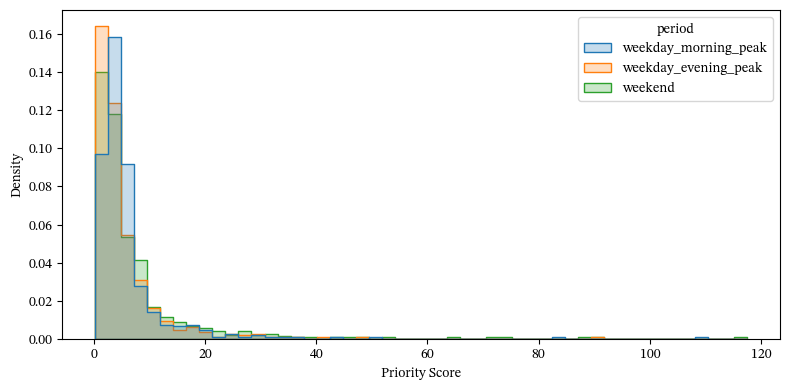

In [79]:
# Priority score distribution
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    data=priority_by_period,
    x="priority_score",
    hue="period",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax
)

ax.set_xlabel("Priority Score")
ax.set_ylabel("Density")

fig.tight_layout()
fig.savefig("../outputs/plots/priority_distribution.pdf", bbox_inches="tight")
plt.show()

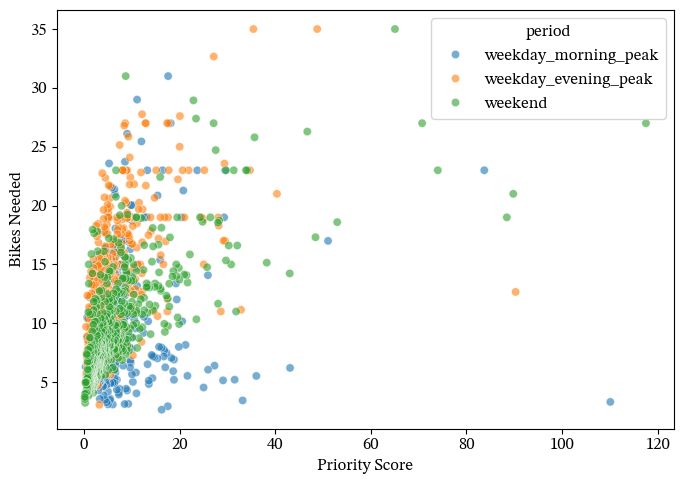

In [55]:
fig, ax = plt.subplots(figsize=(7,5))

sns.scatterplot(
    data=priority_by_period,
    x="priority_score",
    y="bikes_needed",
    hue="period",
    alpha=0.6,
    ax=ax
)

ax.set_xlabel("Priority Score")
ax.set_ylabel("Bikes Needed")

fig.tight_layout()
fig.savefig("../outputs/plots/priority_bikesneeded.pdf", bbox_inches="tight")
plt.show()

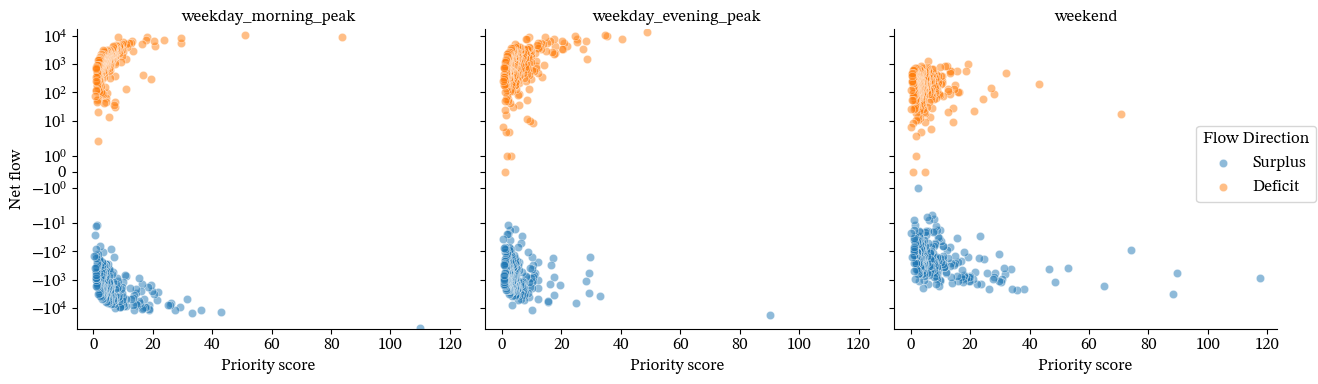

In [47]:
priority_by_period["flow_direction"] = np.where(
    priority_by_period["net_flow"] >= 0,
    "Deficit",
    "Surplus"
)

g = sns.FacetGrid(
    priority_by_period,
    col="period",
    hue="flow_direction",
    sharex=True,
    sharey=True,
    height=4,
    aspect=1.1
)

g.map_dataframe(
    sns.scatterplot,
    x="priority_score",
    y="net_flow",
    alpha=0.5
)

g.set_axis_labels("Priority score", "Net flow")
g.set_titles("{col_name}")
g.add_legend(title="Flow Direction")
g._legend.set_bbox_to_anchor((0.92, 0.55))
g._legend.set_frame_on(True)

for ax in g.axes.flat:
    ax.set_yscale("symlog")

g.tight_layout()
g.savefig("../outputs/plots/priority_netflow_peaks.pdf", bbox_inches="tight")
plt.show()

In [27]:
k = int(0.05 * len(priority_by_period))

# Top 5% by actual imbalance (baseline)
top_imbalance = (
    priority_by_period
    .sort_values("historical_imbalance", ascending=False)
    .head(k)
)

# Top 5% by priority
top_priority = (
    priority_by_period
    .sort_values("priority_score", ascending=False)
    .head(k)
)

capture_priority = (
    top_priority["historical_imbalance"].sum() /
    priority_by_period["historical_imbalance"].sum()
)

capture_imbalance = (
    top_imbalance["historical_imbalance"].sum() /
    priority_by_period["historical_imbalance"].sum()
)

overlap = len(
    set(top_priority["station_id"]) &
    set(top_imbalance["station_id"])
) / k

print(f"Top 5% by priority captures: {capture_priority:.2%} of imbalance")
print(f"Top 5% by imbalance captures: {capture_imbalance:.2%} of imbalance")
print(f"Overlap between selections: {overlap:.2%}")

Top 5% by priority captures: 12.37% of imbalance
Top 5% by imbalance captures: 14.66% of imbalance
Overlap between selections: 41.49%


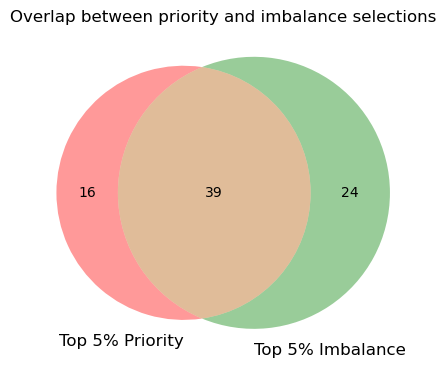

In [31]:
set_priority = set(top_priority["station_id"])
set_imbalance = set(top_imbalance["station_id"])

plt.figure(figsize=(5,5))

venn2(
    [set_priority, set_imbalance],
    set_labels=("Top 5% Priority", "Top 5% Imbalance")
)

plt.title("Overlap between priority and imbalance selections")
plt.show()

In [28]:
comparison_df = top_priority[[
    "station_id",
    "priority_score",
    "historical_imbalance",
    "pred_deficit",
    "pred_surplus"
]].head(10)

comparison_df = comparison_df.sort_values("priority_score", ascending=False)

comparison_df

,station_id,priority_score,historical_imbalance,pred_deficit,pred_surplus
1264,194,117.534886,7740,3351.163080,12915.907419
0,14,110.084015,51573,5.765570,52657.358876
632,548,90.274383,18708,108.577271,19574.475552
1265,27,89.787705,8236,3390.320712,8758.252973
1266,43,88.440271,7709,1810.473141,11819.647150
1,548,83.722297,9383,10591.558209,183.755543
1267,41,74.011624,7227,3196.885866,8543.883407
1268,195,70.728549,6655,3071.803158,9948.107333
1269,14,65.046079,7576,2450.486615,9467.850224
1270,52,52.970796,6049,2120.383352,7514.464067


In [16]:
top_global = (
    priority_by_period
    .sort_values("priority_score", ascending=False)
    .head(15)[[
        "station_id",
        "period",
        "priority_score",
        "bikes_needed",
        "d_i",
        "B_i"
    ]]
)

print(tabulate(top_global, headers="keys", tablefmt="github", showindex=False))

|   station_id | period               |   priority_score |   bikes_needed |      d_i |      B_i |
|--------------|----------------------|------------------|----------------|----------|----------|
|          194 | weekend              |         117.535  |       27       | 23963.3  | 16267.1  |
|           14 | weekday_morning_peak |         110.084  |        3.31732 |  5773.41 | 52663.1  |
|          548 | weekday_evening_peak |          90.2744 |       12.665   | 16183.1  | 19683.1  |
|           27 | weekend              |          89.7877 |       21       | 24512.1  | 12148.6  |
|           43 | weekend              |          88.4403 |       19       | 21519.8  | 13630.1  |
|          548 | weekday_morning_peak |          83.7223 |       23       | 21459.8  | 10775.3  |
|           41 | weekend              |          74.0116 |       23       | 20907    | 11740.8  |
|          195 | weekend              |          70.7285 |       27       | 18016.7  | 13019.9  |
|           14 | wee

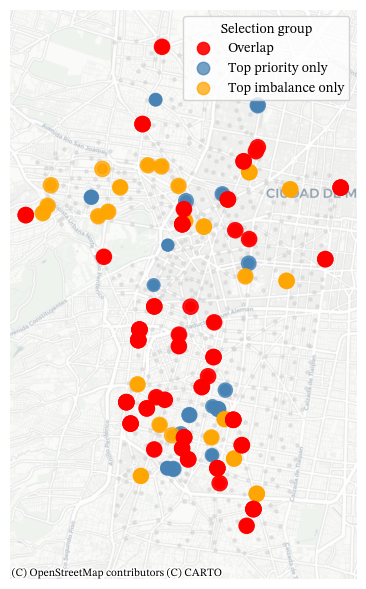

In [ ]:
set_priority = set(top_priority["station_id"])
set_imbalance = set(top_imbalance["station_id"])
set_overlap = set_priority & set_imbalance

overlay_df = priority_by_period.dropna(subset=["lat", "lon"]).copy()

def classify_station(sid):
    if sid in set_overlap:
        return "Overlap"
    elif sid in set_priority:
        return "Top priority only"
    elif sid in set_imbalance:
        return "Top imbalance only"
    else:
        return "Other"

overlay_df["selection_group"] = overlay_df["station_id"].apply(classify_station)

gdf = gpd.GeoDataFrame(
    overlay_df,
    geometry=gpd.points_from_xy(overlay_df["lon"], overlay_df["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Point size by historical imbalance
gdf["size"] = np.clip(
    gdf["historical_imbalance"] / gdf["historical_imbalance"].quantile(0.95) * 120,
    10,
    120
)

fig, ax = plt.subplots(figsize=(5, 6))

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIX Two Text"],
    "font.size": 10
})

# Background stations
gdf[gdf["selection_group"] == "Other"].plot(
    ax=ax,
    markersize=5,
    alpha=0.18,
    color="lightgray"
)

# Plot in preferred legend order
plot_specs = {
    "Overlap": {
        "color": "red",
        "alpha": 0.90,
        "zorder": 4
    },
    "Top priority only": {
        "color": "steelblue",
        "alpha": 0.75,
        "zorder": 3
    },
    "Top imbalance only": {
        "color": "orange",
        "alpha": 0.75,
        "zorder": 3
    }
}

for group, spec in plot_specs.items():
    subset = gdf[gdf["selection_group"] == group]
    subset.plot(
        ax=ax,
        markersize=subset["size"],
        alpha=spec["alpha"],
        color=spec["color"],
        label=group,
        zorder=spec["zorder"]
    )

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

#ax.set_title("Spatial overlap of top 5% priority and imbalance stations")
ax.set_axis_off()
ax.legend(title="Selection group", loc="upper right")

plt.tight_layout()
fig.savefig("../outputs/plots/top5_priority_imbalance_map.pdf", bbox_inches="tight")
plt.show()